In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setup and data preparation

In [16]:
# Consistent plot styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 4)

# Load data
products = pd.read_csv("../data/products.csv")
sales = pd.read_csv("../data/sales.csv",     parse_dates=["sale_date"])
inventory = pd.read_csv("../data/inventory.csv", parse_dates=["snapshot_date"])

print(products.shape, sales.shape, inventory.shape)

(15, 5) (1350, 4) (1350, 4)


### Note: The data used is generated using a python script to mimick a realistic inventory stock. The cells below go into more detail

In [5]:
print("=== PRODUCTS ===")
print(products.dtypes, "\n")
print(products.head(), "\n")

print("=== SALES ===")
print(sales.dtypes, "\n")
print(sales.head(), "\n")

print("=== INVENTORY ===")
print(inventory.dtypes, "\n")
print(inventory.head())

=== PRODUCTS ===
product_id           int64
name                object
category            object
shelf_life_days      int64
avg_daily_demand     int64
dtype: object 

   product_id      name    category  shelf_life_days  avg_daily_demand
0           1   Bananas  Perishable                5                40
1           2    Apples  Perishable                7                30
2           3  Tomatoes  Perishable                4                25
3           4   Lettuce  Perishable                3                15
4           5   Carrots  Perishable               10                20 

=== SALES ===
sale_id                   int64
product_id                int64
quantity_sold             int64
sale_date        datetime64[ns]
dtype: object 

   sale_id  product_id  quantity_sold  sale_date
0        1           1             54 2024-01-01
1        2           1             33 2024-01-02
2        3           1             48 2024-01-03
3        4           1             51 2024-01-04
4

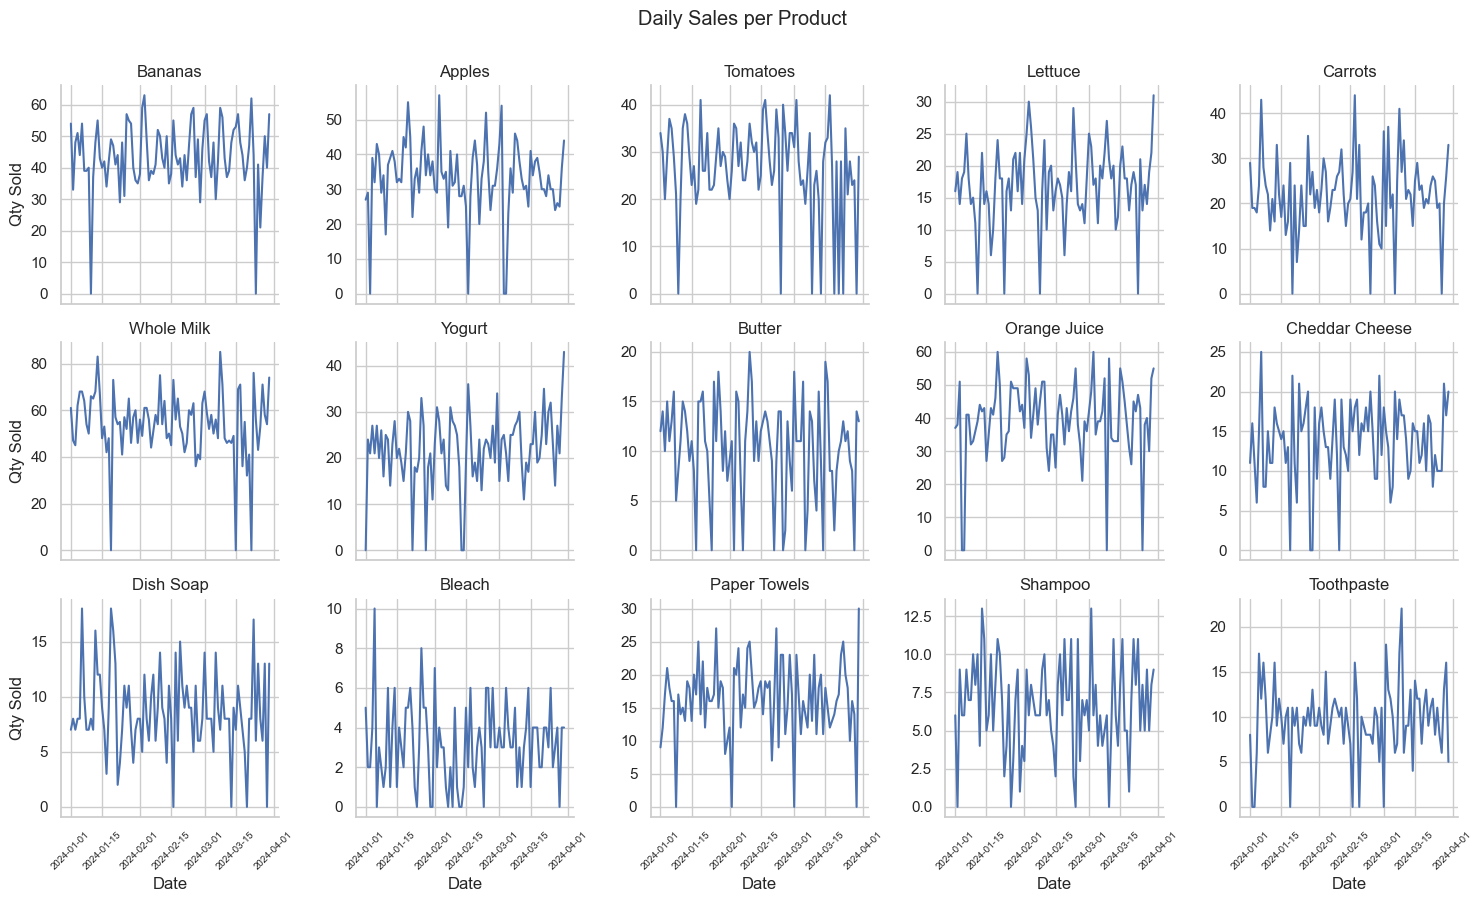

In [32]:
# Merge product names into sales
sales_named = sales.merge(products[["product_id", "name", "category"]], on="product_id")

# Plot each product's daily sales
g = sns.FacetGrid(sales_named, col="name", col_wrap=5, height=3, sharey=False)
g.map_dataframe(sns.lineplot, x="sale_date", y="quantity_sold")
g.set_titles("{col_name}")
g.set_axis_labels("Date", "Qty Sold")

for ax in g.axes.flatten():
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    
plt.suptitle("Daily Sales per Product", y=1)
plt.tight_layout()
plt.show()

### These graphs showcase the daily sales for each product in the data. Each product has high and low days even with a few 0 sale days. 

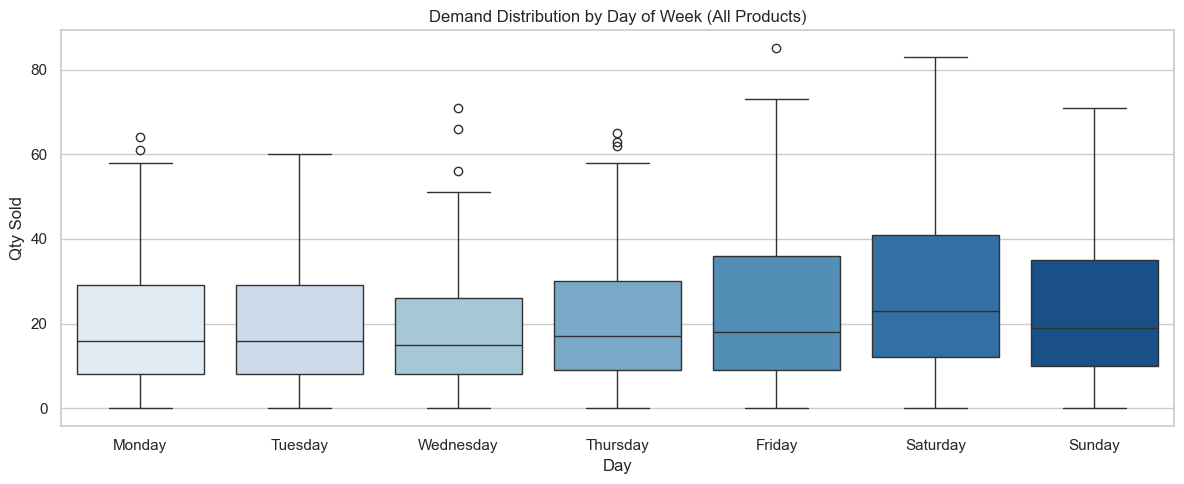

In [29]:
# Weekly check
sales_named["day_of_week"] = sales_named["sale_date"].dt.day_name()

DOW_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=sales_named,
    x="day_of_week",
    y="quantity_sold",
    order=DOW_ORDER,
    hue="day_of_week",
    palette="Blues",
    legend=False
)
plt.title("Demand Distribution by Day of Week (All Products)")
plt.xlabel("Day")
plt.ylabel("Qty Sold")
plt.tight_layout()
plt.show()

### This graph shows that the demand for products is highest heading into and during the weekend, Which is realistic.

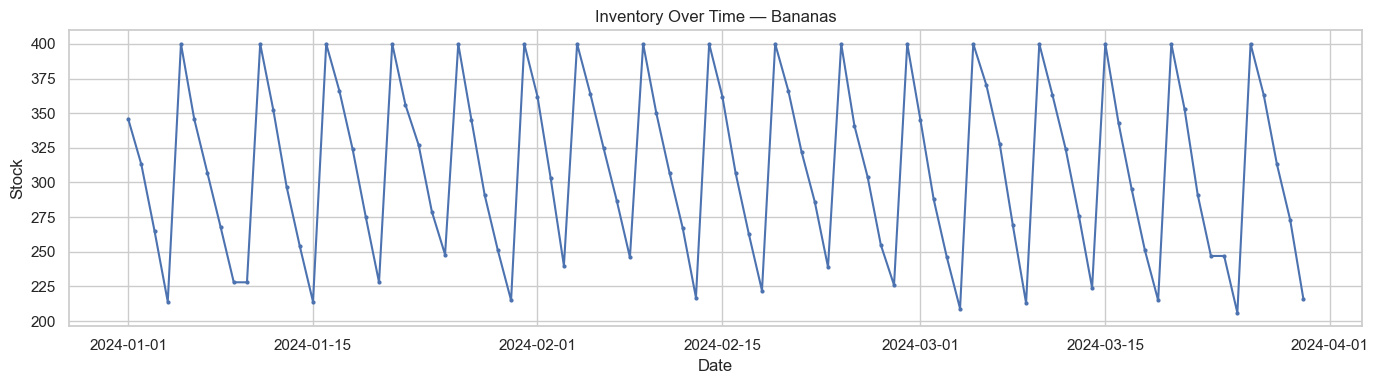

In [30]:
# Pick Bananas (product_id=1) as a representative perishable
product_id = 1
product_name = products.loc[products["product_id"] == product_id, "name"].values[0]
inv_product = inventory[inventory["product_id"] == product_id]

plt.figure(figsize=(14, 4))
plt.plot(inv_product["snapshot_date"], inv_product["current_stock"], marker="o", markersize=2)
plt.title(f"Inventory Over Time — {product_name}")
plt.xlabel("Date")
plt.ylabel("Stock")
plt.tight_layout()
plt.show()

### The graph represents the inventory over time behaviour for products, in this case Bananas.

In [31]:
# Summary stats per category
summary = (
    sales_named
    .groupby("category")["quantity_sold"]
    .agg(["mean", "std", "min", "max"])
    .round(2)
)
print(summary)

               mean    std  min  max
category                            
Household      8.84   5.82    0   30
Perishable    28.40  13.14    0   63
Refrigerated  27.81  19.15    0   85


### This summary is to show that categories behave differently from each other.